In [ ]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import soupx
import scrublet as scr

In [2]:
# Load the last checkpoint
processed_data_path = "../data/processed"
adata = sc.read_h5ad(f"{processed_data_path}/02_cell_gene_filtering.h5ad")

In [3]:
# Make a temporary copy to avoid messing up the main data
adata_tmp = adata.copy()

# Quick processing for a quick Leiden clustering 
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)
sc.pp.pca(adata_tmp)
sc.pp.neighbors(adata_tmp)
sc.tl.leiden(adata_tmp, key_added="soupx_clustering")

# Grab the cluster labels and store them in the real "adata" object.
adata.obs["soupx_clustering"] = adata_tmp.obs["soupx_clustering"]

del adata_tmp

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.
/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/b0/nvzw55rs7y92rywcfyhwkq_xc2qgzh/T/ipykernel_13626/3298792062.py:9: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_tmp, key_added="soupx_clustering")


In [4]:
# Load the raw, unfiltered matrix.
raw_mtx_dir = "../results/starsolo/run_43349135/Solo.out/Gene/raw"
adata_raw = sc.read_10x_mtx(raw_mtx_dir)
adata_raw.var_names_make_unique()

/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/scanpy/readwrite.py:570: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD116-1', 'SNORD116-2', 'SNORD116-3', 'SNORD116-4', 'SNORD116-5']
  adata = _read_10x_mtx(


In [5]:
# Make sure barcodes match between filtered "adata" and adata_raw
print(f"Cells in current filtered adata: {adata.n_obs}")
print(f"Barcodes in raw: {adata_raw.n_obs}")
print(f"Overlap: {len(adata.obs_names.intersection(adata_raw.obs_names))}")

Cells in current filtered adata: 3229
Barcodes in raw: 2812333
Overlap: 3229


In [6]:
# Subset the raw matrix to match the genes kept in the filtered "adata".
adata_raw = adata_raw[:, adata.var_names].copy()

# Extract the original raw UMI integers for the remaining high-quality cells.
# The "toc" (table of cells) is pulled from "adata_raw" to ensure it remains non-normalised and matches the gene order in the "tod" (table of droplets).
adata_filtered_raw = adata_raw[adata.obs_names, :].copy()

# Create the SoupChannel, which is the core container for the correction algorithm.
# We need a table of droplets (tod) vs. a table of cells (toc).
# Because SoupX deals with Genes x Cells, so we transpose.
# ".tocsr()": Ensures the matrix is in Compressed Sparse Row format for fast math.
sc_chan = soupx.SoupChannel(
    tod=adata_raw.X.T.tocsr(),
    toc=adata_filtered_raw.X.T.tocsr(),
    metaData=pd.DataFrame(index=adata.obs_names)
)

# Provide the previous clustering as hints
sc_chan.setClusters(adata.obs["soupx_clustering"].values)
# Compute estimated contamination: the "Rho" value (the %ambient_RNA in the data)
sc_chan = soupx.autoEstCont(sc_chan, verbose=True)
# Subtraction: remove the ambient RNA signal from each cell's expression profile.
corrected_matrix = soupx.adjustCounts(sc_chan)
# Store the corrected counts in a new layer.
# Transpose it back to match the standard Scanpy shape.
adata.layers["soupx_counts"] = corrected_matrix.T

Collapsed to cluster level: (16566, 12) matrix
316 genes passed tf-idf cut-off and 124 soup quantile filter. Taking the top 100.
Found 754 usable gene×cluster combinations for estimation
Using 754 independent estimates of rho.
Estimated global rho of 0.03
Adjusting counts using method 'subtraction' with 12 clusters
Using subtraction method


/Users/wangj/Documents/Computational Biology/Projects/sc-pbmc3k/sc_env/lib/python3.11/site-packages/scipy/sparse/_index.py:216: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


Expanding counts from 12 clusters to 3229 cells (vectorized)


In [7]:
# Sanity check to confirm how the correction has changed the matrix
original_sum = adata.X[0].sum()
soupx_sum = adata.layers["soupx_counts"][0].sum()

print(f"Original UMI count: {original_sum:.0f}")
print(f"SoupX-corrected count: {soupx_sum:.0f}")
print(f"Molecules removed: {original_sum - soupx_sum:.0f}")

Original UMI count: 9589
SoupX-corrected count: 912
Molecules removed: 8677


In [8]:
print(adata.layers)

Layers with keys: raw_counts, soupx_counts


In [9]:
# Initialise Scrublet using the raw counts
# We use the integer layer because Scrublet needs counts.
# A 10X Chromium run is ~0.8% doublet rate for every 1000 cells recovered. 
scrub = scr.Scrublet(adata.layers["raw_counts"], expected_doublet_rate=0.025)
# Default numbers below are empirical. 
doublet_scores, predicted_doublets = scrub.scrub_doublets(
    # before building arteficial doublets, Scrublet ignores genes that are too low.
    min_counts=2,
    min_cells=3,
    # for simulating arteficial doublets, use the top 15% of the highest variable genes (opposite to housekeeping genes).
    min_gene_variability_pctl=85,
    # 30 Principal Components are used as industry-standard resolution for kNN graph construction, balancing biological detail and the risk of overfitting.
    n_prin_comps=30,
    # In small datasets (3,229) or low-variance datasets, the approximation can "oversimplify" the data, rounding different distances to the same value and causing the score collapse I previously saw.
    # Setting it to False uses a brute-force calculation.
    use_approx_neighbors=False,
    distance_metric="euclidean",
)

# Save to adata.
adata.obs["doublet_score_scrublet"] = doublet_scores
adata.obs["predicted_doublet_scrublet"] = predicted_doublets

Preprocessing...
Simulating doublets...
Embedding transcriptomes using PCA...
Calculating doublet scores...
Automatically set threshold at doublet score = 0.28
Detected doublet rate = 0.5%
Estimated detectable doublet fraction = 23.3%
Overall doublet rate:
	Expected   = 2.5%
	Estimated  = 2.1%
Elapsed time: 1.1 seconds


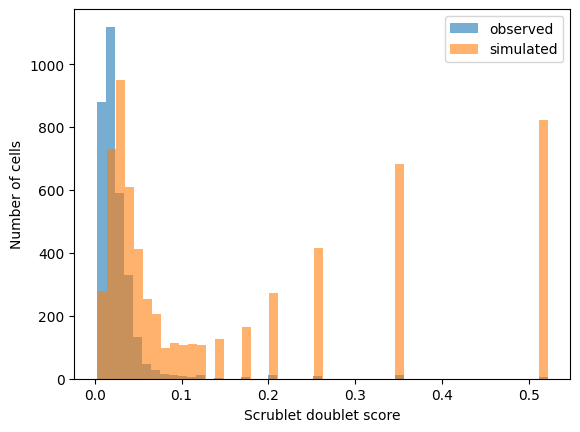

In [10]:
plt.figure()
# Plots the observed scores (the 3,229 cells in your experiment).
# Most of these should have very low scores.
plt.hist(scrub.doublet_scores_obs_, bins=50, alpha=0.6, label="observed")
# Plots the simulated scores (the artificial doublets). 
# These should have higher scores.
plt.hist(scrub.doublet_scores_sim_, bins=50, alpha=0.6,label="simulated")
plt.xlabel("Scrublet doublet score")
plt.ylabel("Number of cells")
plt.legend()
plt.show()

(<Figure size 800x300 with 2 Axes>,
 array([<Axes: title={'center': 'Observed transcriptomes'}, xlabel='Doublet score', ylabel='Prob. density'>,
        <Axes: title={'center': 'Simulated doublets'}, xlabel='Doublet score', ylabel='Prob. density'>],
       dtype=object))

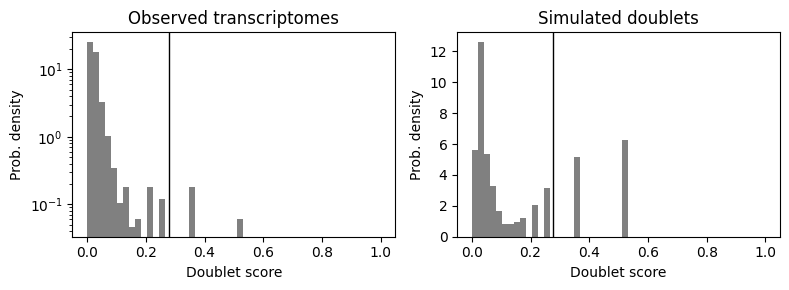

In [11]:
scrub.plot_histogram()

In [12]:
print(predicted_doublets.sum(), "/", len(predicted_doublets))
print(f"threshold: {scrub.threshold_}")

16 / 3229
threshold: 0.27760571388183786


/opt/anaconda3/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


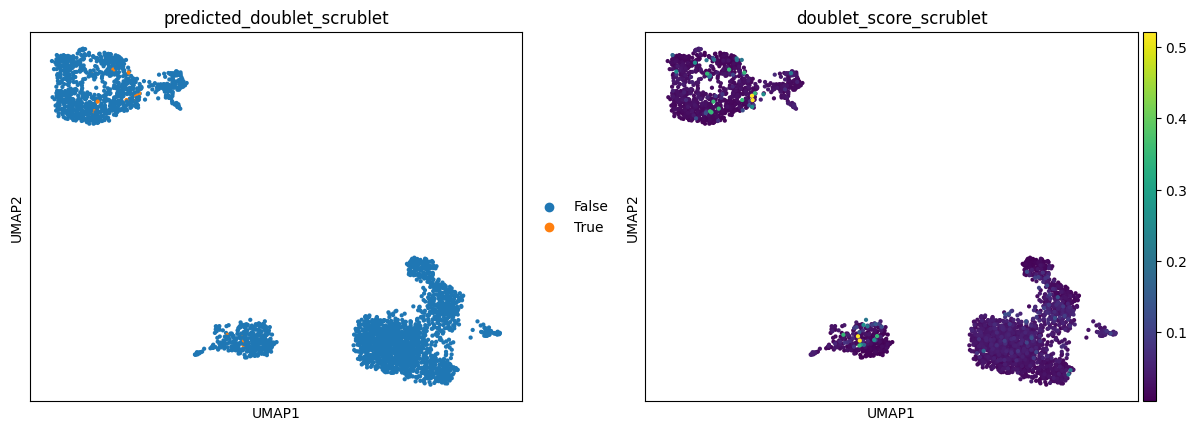

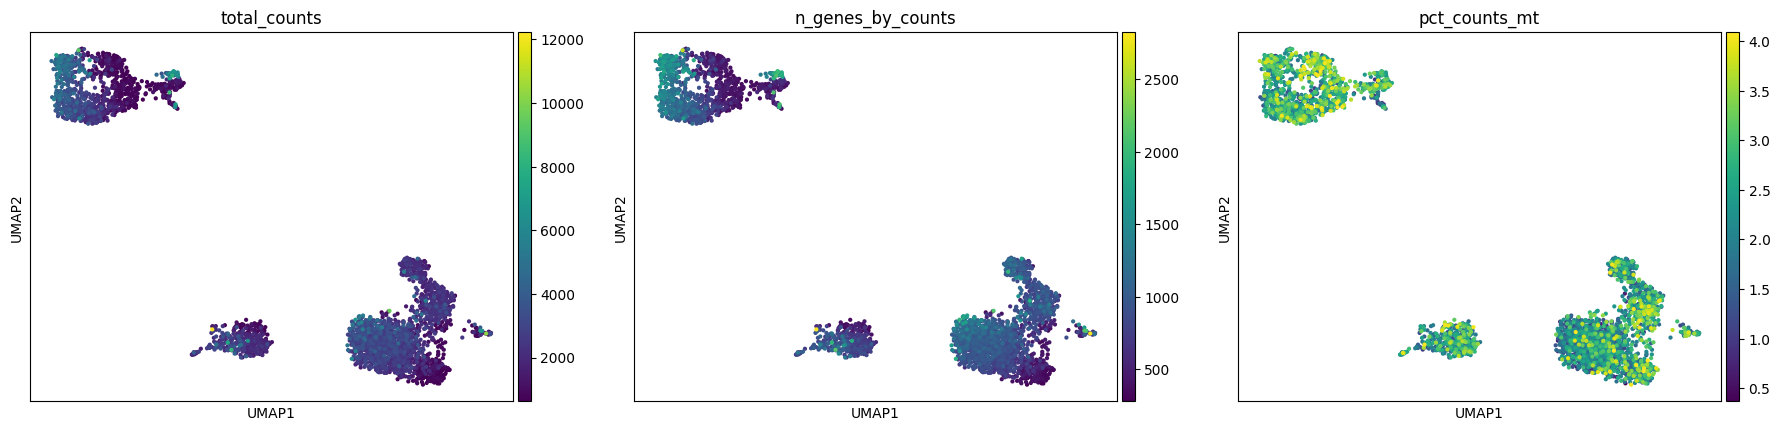

In [13]:
# For now, keep the doublets.
adata_tmp = adata.copy()
adata_tmp.X = adata_tmp.layers["soupx_counts"].copy()
sc.pp.normalize_total(adata_tmp, target_sum=1e4)
sc.pp.log1p(adata_tmp)
sc.pp.highly_variable_genes(adata_tmp, n_top_genes=2000, flavor="seurat")
adata_tmp = adata_tmp[:, adata_tmp.var["highly_variable"]].copy()

sc.pp.scale(adata_tmp, max_value=10)
sc.tl.pca(adata_tmp, n_comps=50)

sc.pp.neighbors(adata_tmp, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_tmp)
sc.tl.leiden(adata_tmp, resolution=0.6)

# from the "predicted_doublet_scrublet" plot.
    # We don't see doublet islands, meaning no substantial heterotypic doublet populations.
    # Note, hetrotypic doublets are usually shown as diffuse cloud of points between two clusters or on the edge of clusters.
    # Homotypic doublets are usually not detected by Scrublet.
sc.pl.umap(adata_tmp, color=["predicted_doublet_scrublet", "doublet_score_scrublet"])
sc.pl.umap(adata_tmp, color=["total_counts", "n_genes_by_counts", "pct_counts_mt"])


In [14]:
# Final decision: filter out identified doublets from the adata.
adata = adata[adata.obs["predicted_doublet_scrublet"] == False].copy()

# Summary of the clean data
print(f"Final Cells: {adata.n_obs}")

Final Cells: 3213


In [ ]:
# Save checkpoint.
adata.write_h5ad(f"{processed_data_path}/03_ambientRNA_cellDoublet_filtering.h5ad")